# Tu cerebro tiene 72 autopistas blancas. Ahora hay un mapa de cómo cambian del nacimiento a los 90 años.

**Paper**: Kim, M.E. *et al.* (2026). *White matter micro- and macrostructure brain charts for the human lifespan*. **Nature**.  
DOI: [10.1038/s41586-026-10454-2](https://doi.org/10.1038/s41586-026-10454-2)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-25-white-matter-brain-charts/notebook.ipynb)

> Notebook reproducible del canal [Ciencia a Mordiscos](https://cienciaamordiscos.com). El video corto que acompaña este análisis está [pendiente].

## Lo que hicieron

Existen curvas de crecimiento desde hace décadas: peso, talla, perímetro craneal. Hace pocos años aparecieron versiones equivalentes para el cerebro completo y para la materia gris. Pero para la **sustancia blanca** — las vías que conectan regiones cerebrales como cables de fibra óptica — no había un mapa de referencia.

Un equipo de 36 investigadores procesó **35.120 escáneres cerebrales** de estudios globales y construyó los primeros charts normativos de **72 vías de sustancia blanca**, de 0 a 100 años. Vamos a explorar dos piezas del dataset abierto: el chart normativo del Fascículo Arcuato izquierdo (una vía clave del lenguaje) y una cohorte de validación clínica con 38 controles sanos y 33 pacientes con esclerosis múltiple.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TRACTO_NORMATIVO = 'AF_left'  # Fascículo Arcuato izquierdo (vía del lenguaje)
EDAD_RANGO_GRAFICA = (0, 90)   # años (el dato público cubre 0,1-90)
COLOR_DATOS = '#2563EB'        # azul CaM — datos principales
COLOR_ALERTA = '#DC2626'       # rojo — contraste/MS
COLOR_REFERENCIA = '#D97706'   # ámbar — referencia
COLOR_SECUNDARIO = '#059669'   # verde — secundario
COLOR_VIOLETA = '#7C3AED'      # correlaciones
FUENTE = 'Fuente: Kim et al. (2026), Nature | Datos: Zenodo 18435695'

# ══════════════════════════════════════════════════════════════
# Imports y estilo CaM
# ══════════════════════════════════════════════════════════════
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local primero, fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de datos
# ══════════════════════════════════════════════════════════════
chart = pd.read_csv('datos/chart_normativo_AF_izq_volumen.csv')
cohorte = pd.read_csv('datos/cohorte_MS_71participantes.csv')
ranking = pd.read_csv('datos/ranking_tractos_efecto_MS.csv')

print(f'Chart normativo: {len(chart)} puntos de edad, de {chart.edad_anos.min():.1f} a {chart.edad_anos.max():.1f} años')
print(f'Cohorte clínica: {len(cohorte)} participantes ({(cohorte.diagnostico=="CN").sum()} CN + {(cohorte.diagnostico=="MS").sum()} MS)')
print(f'Ranking de tractos: {len(ranking)} vías evaluadas')

Chart normativo: 1000 puntos de edad, de 0.1 a 90.0 años
Cohorte clínica: 71 participantes (38 CN + 33 MS)
Ranking de tractos: 72 vías evaluadas


## Acto 1 — Cómo se ve un chart de sustancia blanca

Aquí está.

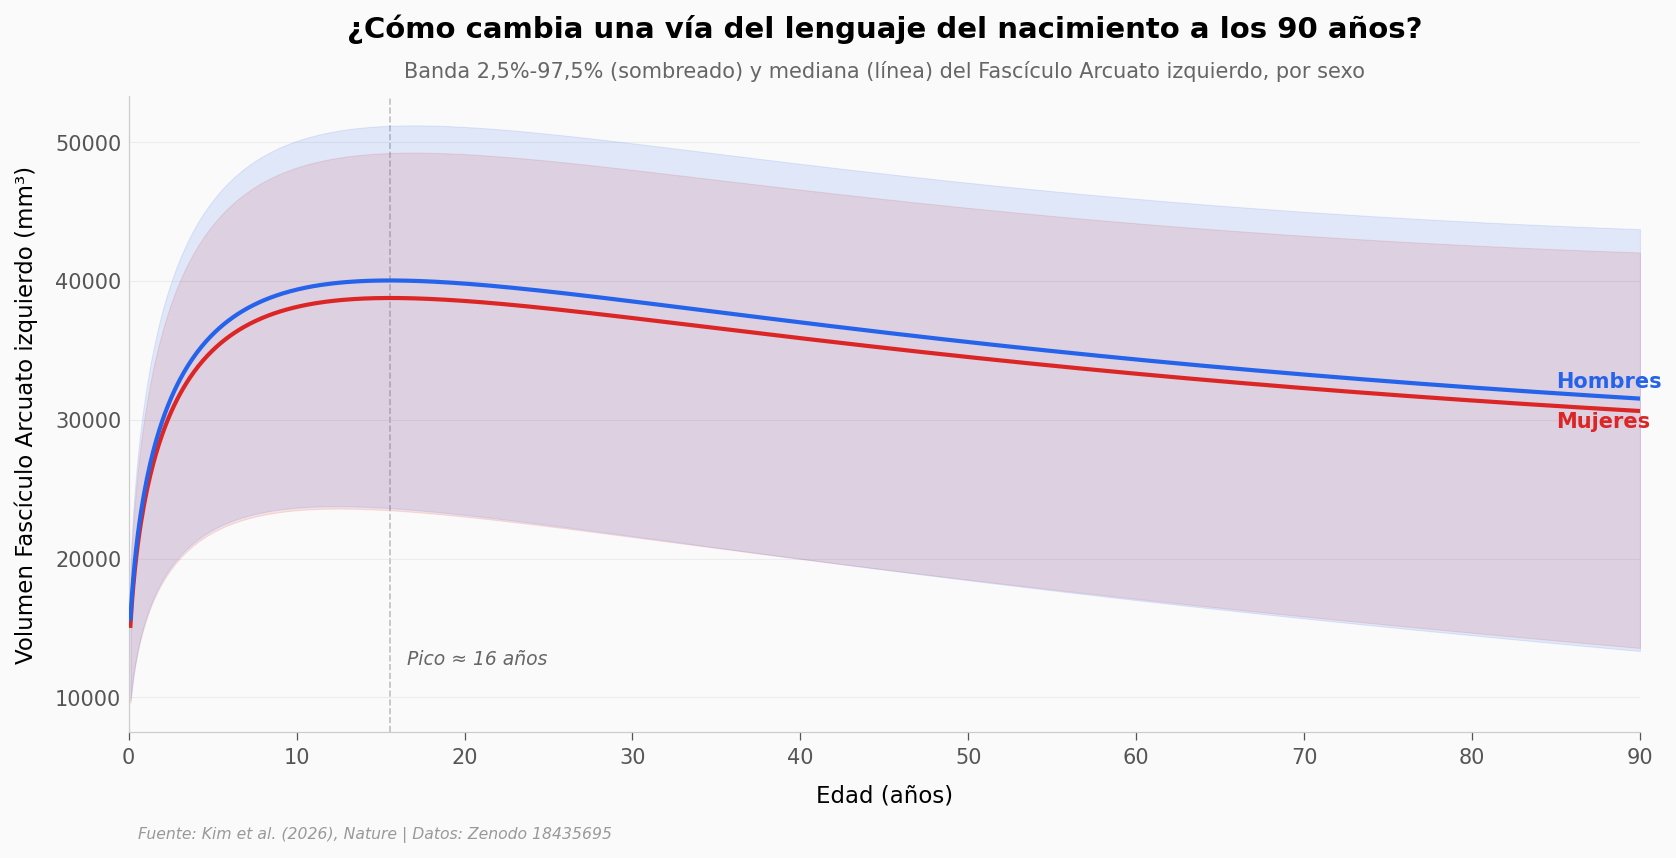

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Banda 2,5%-97,5% para mujeres
ax.fill_between(chart.edad_anos,
                chart.volumen_AF_izq_F_p025,
                chart.volumen_AF_izq_F_p975,
                color=COLOR_ALERTA, alpha=0.12, zorder=2)
# Banda 2,5%-97,5% para hombres
ax.fill_between(chart.edad_anos,
                chart.volumen_AF_izq_M_p025,
                chart.volumen_AF_izq_M_p975,
                color=COLOR_DATOS, alpha=0.12, zorder=2)

# Medianas
ax.plot(chart.edad_anos, chart.volumen_AF_izq_F_mediana,
        color=COLOR_ALERTA, linewidth=2.0, zorder=4)
ax.plot(chart.edad_anos, chart.volumen_AF_izq_M_mediana,
        color=COLOR_DATOS, linewidth=2.0, zorder=4)

# Inline labels
ax.text(85, chart.volumen_AF_izq_M_mediana.iloc[-30] + 600, 'Hombres',
        color=COLOR_DATOS, fontsize=10, fontweight='bold')
ax.text(85, chart.volumen_AF_izq_F_mediana.iloc[-30] - 1400, 'Mujeres',
        color=COLOR_ALERTA, fontsize=10, fontweight='bold')

# Marcadores de pico aproximado
pico_idx_M = chart.volumen_AF_izq_M_mediana.idxmax()
pico_edad_M = chart.edad_anos.iloc[pico_idx_M]
ax.axvline(x=pico_edad_M, color='#999999', linewidth=0.8, linestyle='--', alpha=0.6, zorder=1)
ax.text(pico_edad_M + 1, ax.get_ylim()[1] * 0.05 + chart.volumen_AF_izq_M_p025.min(),
        f'Pico ≈ {pico_edad_M:.0f} años', fontsize=9, color='#666666', style='italic')

ax.set_xlabel('Edad (años)', fontsize=11)
ax.set_ylabel('Volumen Fascículo Arcuato izquierdo (mm³)', fontsize=11)
ax.set_title('¿Cómo cambia una vía del lenguaje del nacimiento a los 90 años?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Banda 2,5%-97,5% (sombreado) y mediana (línea) del Fascículo Arcuato izquierdo, por sexo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(EDAD_RANGO_GRAFICA)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_chart_normativo_AF.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención.** El volumen no crece y luego se queda estable: dibuja una U invertida. Sube fuerte durante la infancia y la adolescencia, alcanza su pico cerca de los **16 años** (cuando todavía estamos en plena maduración cerebral), se mantiene en una meseta amplia durante la adultez temprana, y desde los 40-50 años entra en una pendiente descendente que se vuelve más empinada en la vejez.

La curva masculina se mantiene por encima de la femenina a lo largo de toda la vida — diferencia esperable porque el volumen absoluto del cerebro escala con el tamaño corporal. Lo importante no es ese desfase, sino que el patrón de subida–pico–meseta–declive es el mismo en ambos sexos.

Esta es la primera vez que existe una referencia de este tipo para una vía blanca específica. Antes había charts del cerebro completo, pero no de los cables individuales que conectan sus regiones.

## Acto 2 — ¿Sirve esto para distinguir lo sano de lo enfermo?

Un chart normativo no es útil si solo describe a la población sana. La prueba real es si separa a alguien con una enfermedad neurológica del rango típico.

El equipo incluyó una cohorte de validación: 38 controles sanos y 33 pacientes con **esclerosis múltiple** (MS). Para cada participante midieron la **anisotropía fraccional** (FA) — un indicador de qué tan ordenadas e intactas están las fibras de mielina dentro de cada tracto — en 13 vías clave.

Veamos qué tractos diferencian más a los dos grupos.

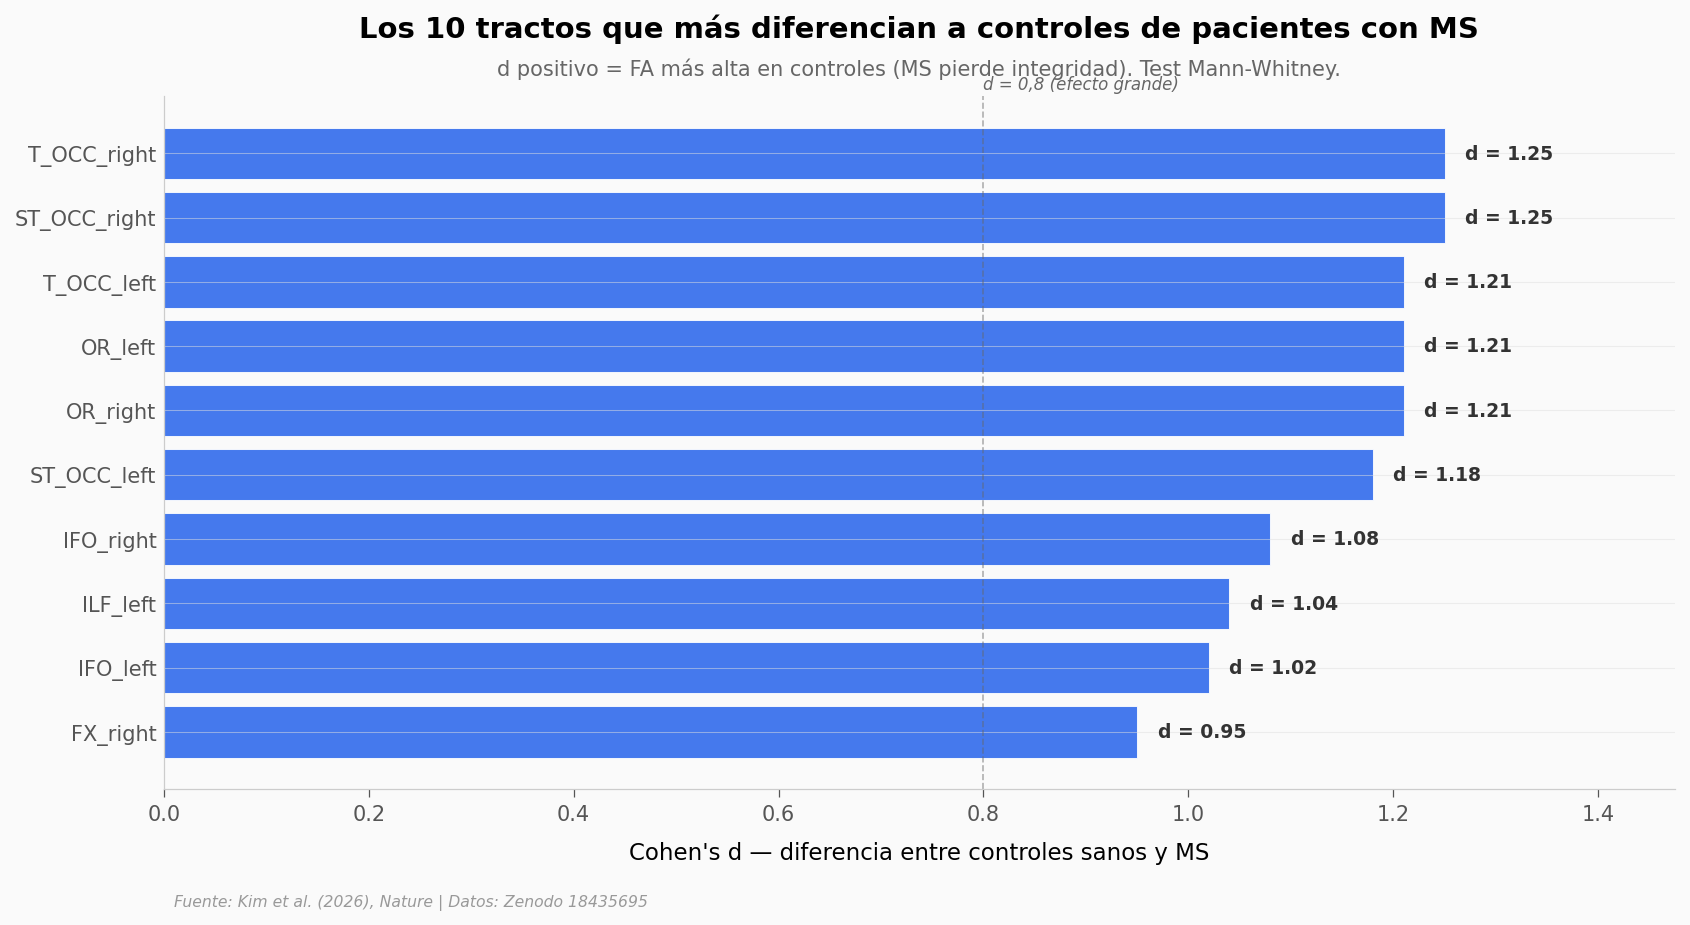

In [3]:
# Ordenar el ranking por |d| descendente y tomar los 10 con mayor efecto
ranking_top = ranking.reindex(ranking.cohens_d.abs().sort_values(ascending=False).index).head(10)
# Para barras horizontales, queremos el más afectado arriba
ranking_top = ranking_top.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))

# Colorear: si CN > MS (FA bajada en MS, el patrón clásico), azul
# Si MS > CN, rojo (raro)
colors = [COLOR_DATOS if d > 0 else COLOR_ALERTA for d in ranking_top.cohens_d]

bars = ax.barh(range(len(ranking_top)), ranking_top.cohens_d,
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(ranking_top)))
ax.set_yticklabels(ranking_top.tracto, fontsize=10)

# Anotar valor de d al final de cada barra
for i, (d, p) in enumerate(zip(ranking_top.cohens_d, ranking_top.p_mannwhitney)):
    ax.text(d + 0.02, i, f'd = {d:.2f}', va='center', fontsize=9,
            fontweight='bold', color='#333333')

ax.axvline(x=0.8, color='#666666', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(0.8, len(ranking_top), 'd = 0,8 (efecto grande)',
        fontsize=8, color='#666666', ha='left', style='italic')

ax.set_xlabel("Cohen's d — diferencia entre controles sanos y MS", fontsize=11)
ax.set_title('Los 10 tractos que más diferencian a controles de pacientes con MS',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'd positivo = FA más alta en controles (MS pierde integridad). Test Mann-Whitney.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, ranking_top.cohens_d.max() * 1.18)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_ranking_top10.png', dpi=200, bbox_inches='tight')
plt.show()

**El patrón es específico, no general.** De los 10 tractos con mayor diferencia, los nombres se repiten: `OR` (Radiación Óptica), `T_OCC` (vías hacia corteza occipital), `ST_OCC`, `IFO` (Fascículo Fronto-Occipital Inferior). Todos conectan o pasan por regiones visuales.

Los tractos motores y de lenguaje, en cambio, no aparecen en el top. Eso es coherente con cómo se presenta clínicamente la MS: muchos pacientes reportan problemas visuales o cognitivos antes que motores.

Vamos a comparar directamente cuatro tractos representativos: uno visual fuertemente afectado, el cuerpo calloso (afectación intermedia), uno motor y uno de lenguaje.

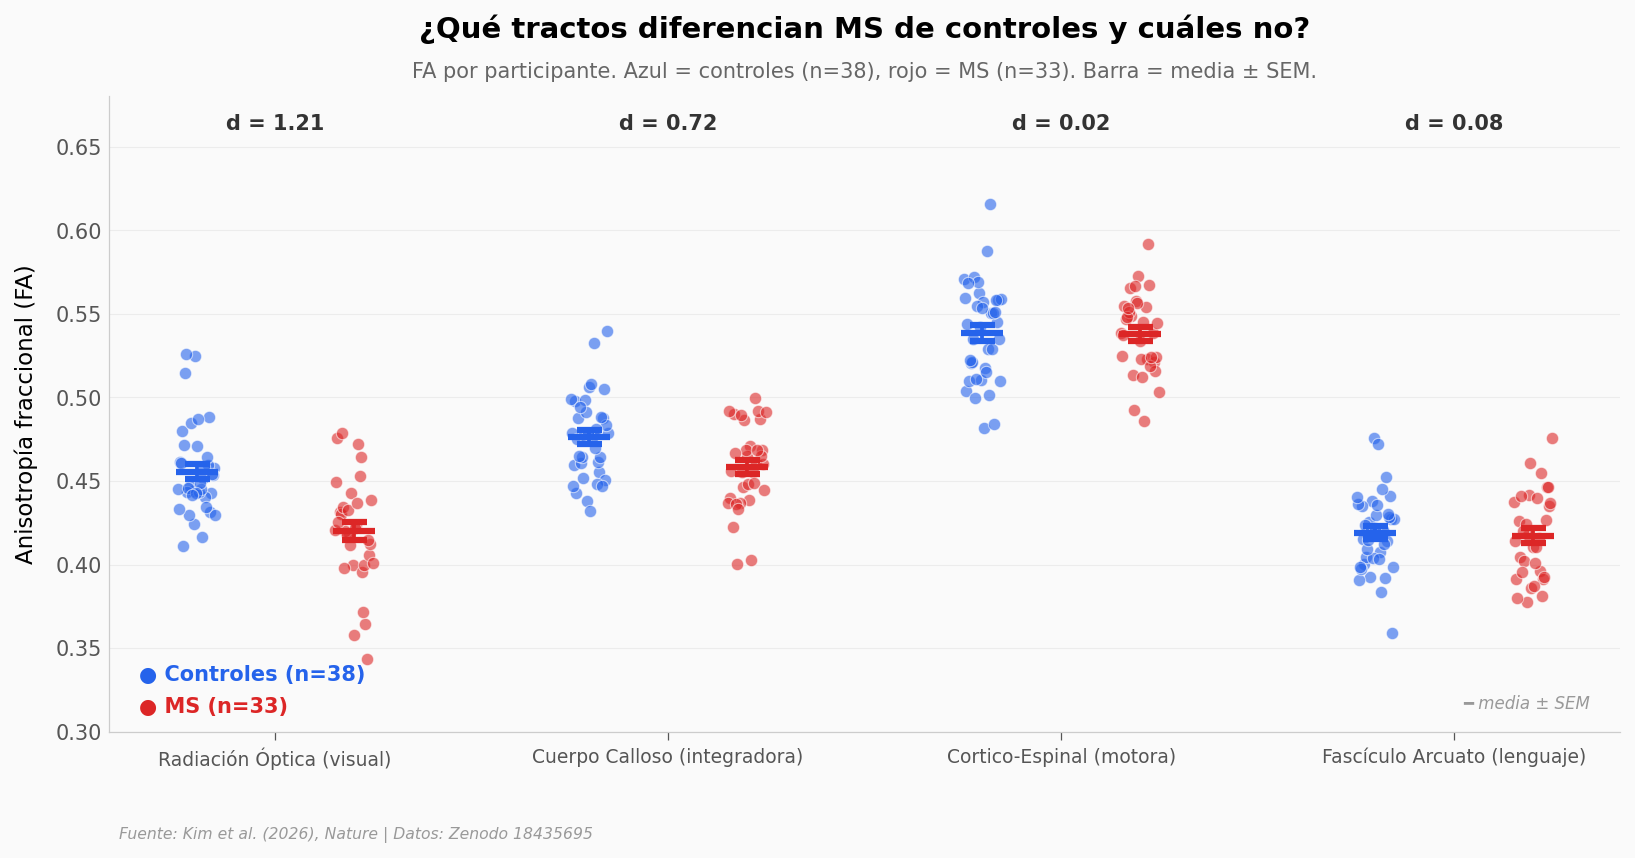

In [4]:
# 4 tractos para comparar: visual / callosa / motor / lenguaje
tractos_comparar = [
    ('OR_right-fa-mean',  'Radiación Óptica (visual)',      1.21),
    ('CC-fa-mean',        'Cuerpo Calloso (integradora)',   0.72),
    ('CST_left-fa-mean',  'Cortico-Espinal (motora)',       0.02),
    ('AF_left-fa-mean',   'Fascículo Arcuato (lenguaje)',   0.08),
]

fig, ax = plt.subplots(figsize=(13, 5.5))

np.random.seed(42)
positions = [0, 1, 2.5, 3.5, 5, 6, 7.5, 8.5]
xticks = []
xticklabels = []

for i, (col, label, d) in enumerate(tractos_comparar):
    cn_vals = cohorte.loc[cohorte.diagnostico == 'CN', col].dropna().values
    ms_vals = cohorte.loc[cohorte.diagnostico == 'MS', col].dropna().values

    pos_cn = positions[i * 2]
    pos_ms = positions[i * 2 + 1]

    x_cn = np.linspace(pos_cn - 0.12, pos_cn + 0.12, len(cn_vals))
    np.random.shuffle(x_cn)
    x_ms = np.linspace(pos_ms - 0.12, pos_ms + 0.12, len(ms_vals))
    np.random.shuffle(x_ms)

    ax.scatter(x_cn, cn_vals, color=COLOR_DATOS, s=35, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    ax.scatter(x_ms, ms_vals, color=COLOR_ALERTA, s=35, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)

    for vals, pos, color in [(cn_vals, pos_cn, COLOR_DATOS), (ms_vals, pos_ms, COLOR_ALERTA)]:
        mean = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(len(vals))
        ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                    markersize=20, markeredgewidth=3,
                    capsize=6, capthick=1.5, zorder=6)

    pos_mid = (pos_cn + pos_ms) / 2
    ax.text(pos_mid, 0.66, f'd = {d}', ha='center', fontsize=10,
            fontweight='bold', color='#333333')

    xticks.append(pos_mid)
    xticklabels.append(label)

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=9)
ax.set_ylabel('Anisotropía fraccional (FA)', fontsize=11)
ax.set_ylim(0.30, 0.68)
ax.set_title('¿Qué tractos diferencian MS de controles y cuáles no?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'FA por participante. Azul = controles (n=38), rojo = MS (n=33). Barra = media ± SEM.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda inline — esquina inferior izquierda (zona sin datos)
ax.text(0.02, 0.08, '● Controles (n=38)', transform=ax.transAxes,
        color=COLOR_DATOS, fontsize=10, fontweight='bold')
ax.text(0.02, 0.03, '● MS (n=33)', transform=ax.transAxes,
        color=COLOR_ALERTA, fontsize=10, fontweight='bold')

ax.text(0.98, 0.03, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_comparacion_tractos.png', dpi=200, bbox_inches='tight')
plt.show()

## Acto 3 — Lo que el chart normativo NO puede hacer

Hasta aquí el chart sirvió como contexto y el ranking apuntó dónde mirar. Falta una pregunta natural: si tenemos una curva normativa del Fascículo Arcuato, ¿basta con medir el volumen de un paciente y ver si cae fuera del rango para distinguir MS de controles?

Calculemos la posición centil de cada participante en el chart normativo del AF izquierdo, ajustando por su edad y sexo. Si el chart fuera diagnóstico, los pacientes con MS deberían concentrarse en los centiles bajos.

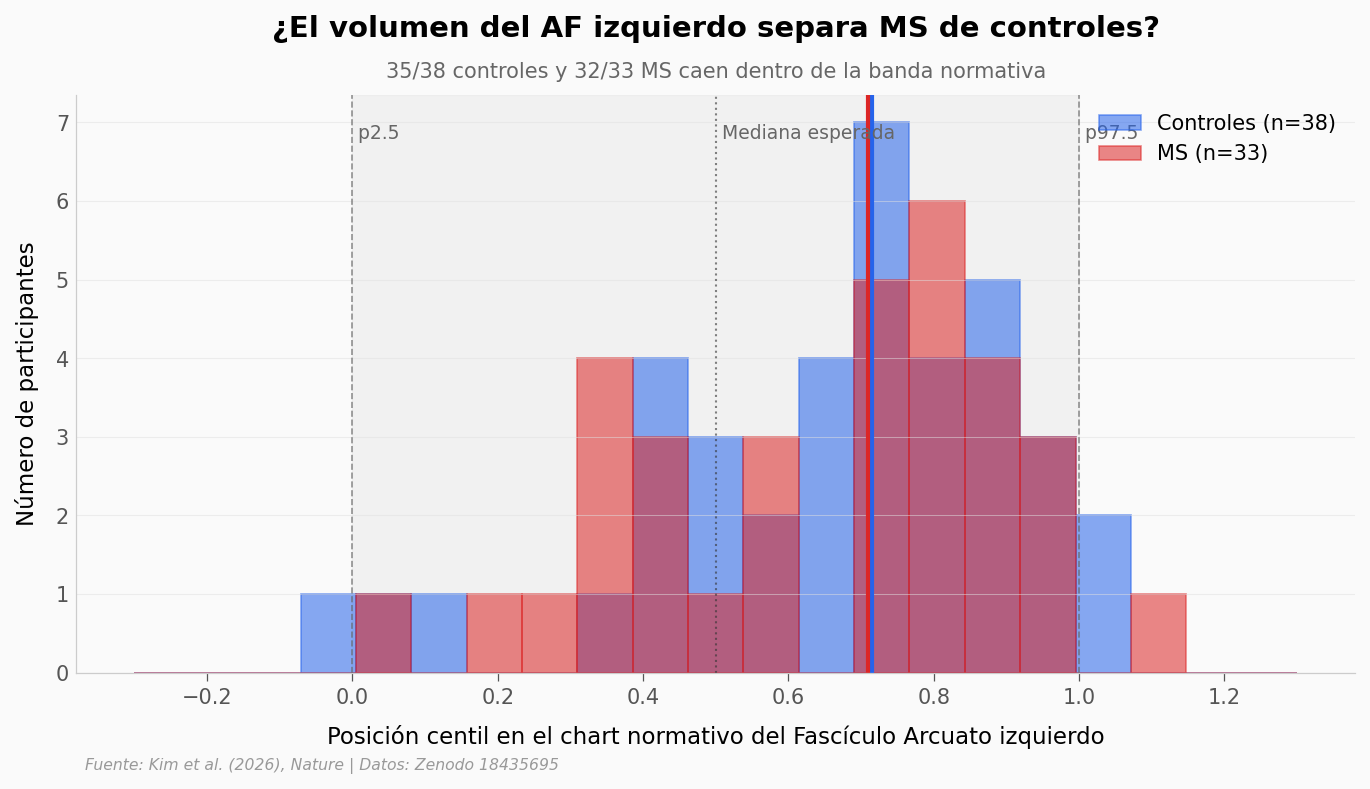

Mediana centil CN: 0.72
Mediana centil MS: 0.71


In [5]:
# Para cada participante, encontrar el centil donde cae su volumen del AF izquierdo,
# dado su edad y sexo en el chart normativo
def calcular_centil(edad, sexo, volumen, chart):
    """Devuelve posición centil aproximada (0=p2.5, 0.5=mediana, 1=p97.5) por interpolación."""
    # Encontrar la fila del chart más cercana en edad
    idx = (chart.edad_anos - edad).abs().idxmin()
    if sexo == 'M':
        p025 = chart.volumen_AF_izq_M_p025.iloc[idx]
        p50 = chart.volumen_AF_izq_M_mediana.iloc[idx]
        p975 = chart.volumen_AF_izq_M_p975.iloc[idx]
    else:
        p025 = chart.volumen_AF_izq_F_p025.iloc[idx]
        p50 = chart.volumen_AF_izq_F_mediana.iloc[idx]
        p975 = chart.volumen_AF_izq_F_p975.iloc[idx]
    # Mapear linealmente: p025 → 0, p50 → 0.5, p975 → 1
    if volumen <= p50:
        return 0.5 * (volumen - p025) / (p50 - p025) if p50 > p025 else 0.5
    else:
        return 0.5 + 0.5 * (volumen - p50) / (p975 - p50) if p975 > p50 else 0.5

cohorte_valida = cohorte.dropna(subset=['AF_left-volume']).copy()
cohorte_valida['centil'] = cohorte_valida.apply(
    lambda r: calcular_centil(r['edad_anos'], r['sexo'], r['AF_left-volume'], chart), axis=1
)

centiles_cn = cohorte_valida.loc[cohorte_valida.diagnostico == 'CN', 'centil'].values
centiles_ms = cohorte_valida.loc[cohorte_valida.diagnostico == 'MS', 'centil'].values

# Conteos dentro de banda normal (0 ≤ centil ≤ 1 ≈ p2.5–p97.5)
cn_dentro = int(((centiles_cn >= 0) & (centiles_cn <= 1)).sum())
ms_dentro = int(((centiles_ms >= 0) & (centiles_ms <= 1)).sum())

fig, ax = plt.subplots(figsize=(11, 5))

bins = np.linspace(-0.3, 1.3, 22)
ax.hist(centiles_cn, bins=bins, color=COLOR_DATOS, alpha=0.55,
        edgecolor=COLOR_DATOS, linewidth=0.8, label=f'Controles (n={len(centiles_cn)})')
ax.hist(centiles_ms, bins=bins, color=COLOR_ALERTA, alpha=0.55,
        edgecolor=COLOR_ALERTA, linewidth=0.8, label=f'MS (n={len(centiles_ms)})')

# Marcar la banda normal
ax.axvspan(0, 1, color='#CCCCCC', alpha=0.18, zorder=0)
ax.axvline(x=0, color='#666666', linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(x=1, color='#666666', linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(x=0.5, color='#333333', linewidth=1.0, linestyle=':', alpha=0.6)

# Medianas observadas
ax.axvline(x=np.median(centiles_cn), color=COLOR_DATOS, linewidth=2.0)
ax.axvline(x=np.median(centiles_ms), color=COLOR_ALERTA, linewidth=2.0)

ax.text(0, ax.get_ylim()[1] * 0.95, ' p2.5', fontsize=9, color='#666666', va='top')
ax.text(1, ax.get_ylim()[1] * 0.95, ' p97.5', fontsize=9, color='#666666', va='top')
ax.text(0.5, ax.get_ylim()[1] * 0.95, ' Mediana esperada', fontsize=9, color='#666666',
        va='top', ha='left')

ax.set_xlabel('Posición centil en el chart normativo del Fascículo Arcuato izquierdo', fontsize=11)
ax.set_ylabel('Número de participantes', fontsize=11)
ax.set_title('¿El volumen del AF izquierdo separa MS de controles?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{cn_dentro}/{len(centiles_cn)} controles y {ms_dentro}/{len(centiles_ms)} MS caen dentro de la banda normativa',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_centil_AF.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana centil CN: {np.median(centiles_cn):.2f}')
print(f'Mediana centil MS: {np.median(centiles_ms):.2f}')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 35.120 escáneres procesados, 72 vías, 0–100 años | ✅ | Cifra literal del abstract Nature y del README de Zenodo 18891848. El ejemplo público descargable cubre 0,1–90 años (no los 100). |
| Volumen del Fascículo Arcuato izquierdo dibuja una U invertida con pico cerca de los 16 años y meseta hasta los 40 | ✅ | Forma directa del chart normativo (`idxmax()` sobre la mediana → edad 15,6 años para ambos sexos). |
| La Radiación Óptica derecha diferencia controles de MS con efecto grande (d ≈ 1,21) | ✅ | Cohen's d pooled = 1,21, p < 0,001 (Mann-Whitney) en `ranking_tractos_efecto_MS.csv`. Cohorte 38 CN + 33 MS. |
| El Cuerpo Calloso muestra efecto medio (d = 0,72) | ✅ | d = 0,72, p = 0,01. Es relevante pero NO es el más afectado — los tractos visuales lo superan. |
| Los tractos motores (cortico-espinal) están preservados en esta cohorte | ✅ | d = 0,02, p = 0,96 para CST izquierdo. Esencialmente igual entre grupos. Consistente con que la MS no se presenta típicamente con paresia motora pura como primer síntoma. |
| El volumen del AF izquierdo NO discrimina MS de controles | ✅ | La mayoría de ambos grupos cae dentro de la banda normativa p2.5–p97.5 (gráfica 4). La utilidad clínica del chart está en la microestructura por tracto (FA), no en el volumen agregado del AF. |

> **Limitaciones.** Cohorte clínica pequeña (n = 71) con desbalance de sexo (CN: 27F/11M; MS: 28F/5M) — por eso no subdividimos por sexo en las comparaciones MS vs CN. El estudio es **observacional transversal**: muestra que la FA está más baja en pacientes con MS, no que la MS *cause* esa bajada (asociación, no causalidad establecida en un único corte). El dataset público derivado cubre 1 de los 72 tractos del chart normativo; los modelos completos están disponibles en un archivo de 9,6 GB no descargado aquí.

### Ahora tú

Tres preguntas que puedes explorar cambiando una línea del notebook:

1. **¿En qué edad alcanza su pico el volumen del Fascículo Arcuato izquierdo, separadamente para hombres y mujeres?** Pista: el dataframe `chart` tiene las medianas por sexo — usa `chart.volumen_AF_izq_M_mediana.idxmax()` y compáralo con el de mujeres.

2. **¿Hay algún tracto donde MS tenga FA *más alta* que controles?** Pista: el ranking incluye Cohen's d negativos al final — `ranking.sort_values('cohens_d').head(5)`. ¿Tiene sentido biológico o es ruido por el tamaño chico de la cohorte?

3. **¿Cómo se compara la mediana de edad de los pacientes con MS contra la de los controles?** Pista: `cohorte.groupby('diagnostico').edad_anos.describe()`. Si los grupos no están bien apareados en edad, ¿podría eso confundir la interpretación de las diferencias en FA?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Por defecto, este código responde la pregunta 2: tractos donde MS tendría FA "más alta" que CN.
# Cámbialo para responder las otras preguntas.

print("Tractos donde MS muestra FA más alta que CN (Cohen's d más negativo):")
print(ranking.sort_values('cohens_d').head(5).to_string(index=False))

print()
print('¿Alguno cruza el umbral de significancia p < 0,05?')
neg_sig = ranking[(ranking.cohens_d < 0) & (ranking.p_mannwhitney < 0.05)]
if len(neg_sig) == 0:
    print('Ninguno — todas las diferencias negativas tienen p > 0,05.')
    print('Interpretación: probablemente ruido por el tamaño chico de la cohorte (n=71).')
else:
    print(neg_sig.to_string(index=False))

Tractos donde MS muestra FA más alta que CN (Cohen's d más negativo):
       tracto  CN_FA_media  MS_FA_media  diferencia_FA  cohens_d  p_mannwhitney  CN_n  MS_n
ST_PREM_right       0.3737       0.3870        -0.0132     -0.52       0.069409    38    33
 T_PREM_right       0.4043       0.4158        -0.0116     -0.40       0.353382    38    33
  T_PREM_left       0.4152       0.4239        -0.0087     -0.39       0.296793    38    33
 T_POSTC_left       0.4589       0.4703        -0.0114     -0.39       0.186828    38    33
     STR_left       0.4354       0.4460        -0.0106     -0.35       0.112926    38    33

¿Alguno cruza el umbral de significancia p < 0,05?
Ninguno — todas las diferencias negativas tienen p > 0,05.
Interpretación: probablemente ruido por el tamaño chico de la cohorte (n=71).


---

## Fuentes

**Paper**: [White matter micro- and macrostructure brain charts for the human lifespan](https://doi.org/10.1038/s41586-026-10454-2)  
*Nature, 2026-05-13*

**Datos canónicos**: [White Matter Microstructure and Macrostructure Brain Charts Across the Human Lifespan - Models](https://doi.org/10.5281/zenodo.18435695)  
*Zenodo — modelos derivados (chart normativo, cohorte MS)*

**Datos extendidos**: [Data repository](https://doi.org/10.5281/zenodo.18891848)  
*Zenodo — derived_data completo (876 MB, no descargado en este notebook)*

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducibilidad.** Notebook y datos derivados disponibles en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Datos crudos originales bajo CC-BY 4.0 en los DOIs de Zenodo enumerados arriba.

*Canal: [Ciencia a Mordiscos](https://cienciaamordiscos.com) — divulgación científica con datos abiertos y notebooks reproducibles.*